# Exercise: Stereo Vision & Disparity Map Estimation

This notebook demonstrates how to go from **two images of the same scene** (a stereo pair) to a **disparity map**, which represents the relative depth of objects in the scene.

---

## **Steps and Learning Objectives**

1. **Feature Detection and Matching**
   - Detect keypoints in both images using ORB.
   - Match features to find correspondences between the left and right images.
   - **Learning goal:** Understand how finding matching points across images is the foundation of depth estimation.

2. **Fundamental Matrix Estimation**
   - Compute the fundamental matrix `F` using RANSAC to encode epipolar geometry.
   - Filter out outlier matches that don’t fit the geometric model.
   - **Learning goal:** Learn how stereo geometry constrains where corresponding points can lie in the second image.

3. **Stereo Rectification**
   - Warp both images so that corresponding points lie on the **same horizontal line**.
   - Simplifies the search for corresponding pixels when computing disparity.
   - **Learning goal:** See how rectification reduces a 2D search problem to a 1D horizontal search, making disparity calculation more reliable.

4. **Epipolar Lines Visualization**
   - Draw epipolar lines and matched points to illustrate the geometric relationship.
   - **Learning goal:** Visualize the constraint that matching points must lie along corresponding lines in the other image.

5. **Disparity Map Computation**
   - Use `StereoBM` to compute the disparity map from the rectified images.
   - The disparity map encodes **how much each pixel shifts between the left and right images**.
   - **Learning goal:** Observe how differences in horizontal positions correspond to relative depth:  
     - Large disparity → closer object  
     - Small disparity → farther object

---

**After going through this notebook:**  
You should be able to:
- Detect and match keypoints between stereo images.
- Understand the role of the fundamental matrix in defining epipolar geometry.
- Rectify images to make disparity computation feasible.
- Compute and visualize a preliminary disparity map to see relative depth.



In [1]:
!pip install matplotlib kiwisolver opencv-python

In [2]:
# Importing required libraries
import time
# OpenCV library for computer vision tasks (like reading, processing images)
import cv2
# NumPy for numerical operations, especially arrays (images are arrays!)
import numpy as np
# Matplotlib for plotting images and graphs
import matplotlib.pyplot as plt

## Download and Upload stereo image examples

We are downloading a small dataset for testing stereo vision algorithms "chess1" is just one scene from the Middlebury Stereo dataset

In [3]:
# Download example data (one scene)
# e.g. “SCENE1” in scenes2021; adjust path as needed
!wget https://vision.middlebury.edu/stereo/data/scenes2021/data/chess1/im0.png
!wget https://vision.middlebury.edu/stereo/data/scenes2021/data/chess1/im1.png
!wget https://vision.middlebury.edu/stereo/data/scenes2021/data/chess1/calib.txt
!wget https://vision.middlebury.edu/stereo/data/scenes2021/data/chess1/disp0.pfm

# cv2.imread reads an image from disk
# cv2.IMREAD_GRAYSCALE converts the image to grayscale (black and white)
# Grayscale images are simpler and often enough for stereo algorithms
# Load images and calibration
img1 = cv2.imread('im0.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('im1.png', cv2.IMREAD_GRAYSCALE)

# Get resolution
height1, width1 = img1.shape
height2, width2 = img2.shape

print(f"Image 1 resolution: {width1} x {height1}")
print(f"Image 2 resolution: {width2} x {height2}")

--2025-10-06 12:56:38--  https://vision.middlebury.edu/stereo/data/scenes2021/data/chess1/im0.png
Resolving vision.middlebury.edu (vision.middlebury.edu)... 140.233.20.14
Connecting to vision.middlebury.edu (vision.middlebury.edu)|140.233.20.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2562011 (2.4M) [image/png]
Saving to: ‘im0.png’

im0.png             100%[===================>]   2.44M  3.90MB/s    in 0.6s    

2025-10-06 12:56:39 (3.90 MB/s) - ‘im0.png’ saved [2562011/2562011]

--2025-10-06 12:56:39--  https://vision.middlebury.edu/stereo/data/scenes2021/data/chess1/im1.png
Resolving vision.middlebury.edu (vision.middlebury.edu)... 140.233.20.14
Connecting to vision.middlebury.edu (vision.middlebury.edu)|140.233.20.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2578461 (2.5M) [image/png]
Saving to: ‘im1.png’

im1.png             100%[===================>]   2.46M  3.93MB/s    in 0.6s    

2025-10-06 12:56:40 (3.93 MB/s) -

## Feature detection & matching

- Create an ORB detector object able to detect keypoints and compute descriptors
- Create a Brute Force Matcher object with Hamming distance
  - Hamming distance is suitable for ORB descriptors (binary descriptors)
  - crossCheck=True ensures matches are consistent in both directions
- Keep only the best 'x' matches

<details>
<summary>✅ Click here to see the solution</summary>

```python
# Full solution code here

# Create an ORB detector object
# We set 5000 as the maximum number of keypoints to detect
orb = cv2.ORB_create(5000)

# Detect keypoints and compute descriptors for both images
# kp1/kp2: list of keypoints (locations in the image)
# des1/des2: descriptors (feature vectors for matching)
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# Create a Brute Force Matcher object with Hamming distance
# Hamming distance is suitable for ORB descriptors (binary descriptors)
# crossCheck=True ensures matches are consistent in both directions
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
# Match descriptors between the two images
matches = bf.match(des1, des2)
# Sort matches by distance (lower distance = better match)
matches = sorted(matches, key=lambda x: x.distance)
# Keep only the top 200 good matches for further processing
good_matches = matches[:200]

# queryIdx: index of the descriptor in the first image
# trainIdx: index of the descriptor in the second image
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

In [5]:
# Create an ORB detector object
# We set 5000 as the maximum number of keypoints to detect
orb = cv2.ORB_create(...)

# Detect keypoints and compute descriptors for both images
# kp1/kp2: list of keypoints (locations in the image)
# des1/des2: descriptors (feature vectors for matching)
kp1, des1 = ...
kp2, des2 = ...

# Create a Brute Force Matcher object with Hamming distance
# Hamming distance is suitable for ORB descriptors (binary descriptors)
# crossCheck=True ensures matches are consistent in both directions
bf = cv2.BFMatcher(...)
# Match descriptors between the two images
matches = bf.match(...)
# Sort matches by distance (lower distance = better match)
matches = sorted(matches, key=lambda x: x.distance)
# Keep only the top 200 good matches for further processing
good_matches = matches[:200]

# queryIdx: index of the descriptor in the first image
# trainIdx: index of the descriptor in the second image
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

## Fundamental Matrix & Rectification

- cv2.findFundamentalMat estimates the fundamental matrix F
- F relates points in the two images (epipolar geometry)
- cv2.FM_RANSAC is used to ignore outlier matches
  - Replace cv2.FM_RANSAC with cv2.FM_LMEDS. Compare results. Which method is more stable?

<details>
<summary>✅ Click here to see the solution</summary>

```python
# Full solution code here

# cv2.findFundamentalMat estimates the fundamental matrix F
# F relates points in the two images (epipolar geometry)
# cv2.FM_RANSAC is used to ignore outlier matches
start = time.time()

F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

if len(pts1) < 8:
    print("Not enough points for rectification after RANSAC. Need at least 8 points.")
else:
    retVal, h1, h2 = cv2.stereoRectifyUncalibrated(pts1, pts2, F, img1.shape[::-1])
    img1_rect = cv2.warpPerspective(img1, h1, img1.shape[::-1])
    img2_rect = cv2.warpPerspective(img2, h2, img2.shape[::-1])

end = time.time()
elapsed_ms_F = (end - start) * 1000
print(f"Time for findFundamentalMat: {elapsed_ms_F:.2f} ms")

In [ ]:
# cv2.findFundamentalMat estimates the fundamental matrix F
# F relates points in the two images (epipolar geometry)
# cv2.FM_RANSAC is used to ignore outlier matches
start = time.time()

F, mask = cv2.findFundamentalMat(...)
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

if len(pts1) < 8:
    print("Not enough points for rectification after RANSAC. Need at least 8 points.")
else:
    retVal, h1, h2 = cv2.stereoRectifyUncalibrated(pts1, pts2, ..., img1.shape[::-1])
    img1_rect = cv2.warpPerspective(img1, ..., img1.shape[::-1])
    img2_rect = cv2.warpPerspective(img2, ..., img2.shape[::-1])

end = time.time()
elapsed_ms_F = (end - start) * 1000
print(f"Time for findFundamentalMat: {elapsed_ms_F:.2f} ms")

Time for findFundamentalMat: 76.86 ms


## Epipolar Lines Visualization

<details>
<summary>✅ Click here to see the solution</summary>

```python
# Warp feature points to rectified geometry
pts1_rect = cv2.perspectiveTransform(pts1.reshape(-1,1,2), h1).reshape(-1,2)
pts2_rect = cv2.perspectiveTransform(pts2.reshape(-1,1,2), h2).reshape(-1,2)

# Use your rectified images and points
img5, img6 = draw_rectified_lines(img1_rect, img2_rect, pts1_rect, pts2_rect)

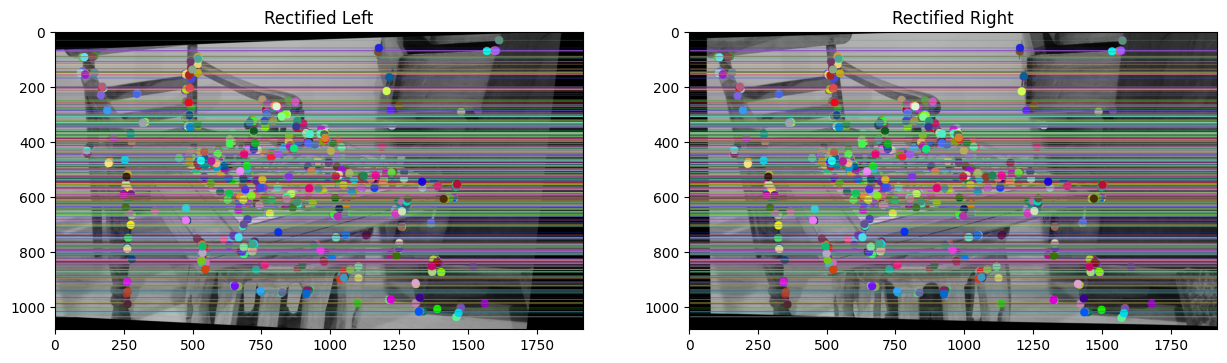

In [ ]:
def draw_rectified_lines(img1_rect, img2_rect, pts1, pts2):
    """
    Draw horizontal epipolar lines on rectified stereo images.
    """
    img1 = cv2.cvtColor(img1_rect, cv2.COLOR_GRAY2BGR)
    img2 = cv2.cvtColor(img2_rect, cv2.COLOR_GRAY2BGR)

    # Go through matches and draw horizontal lines
    for pt1, pt2 in zip(pts1.astype(int), pts2.astype(int)):
        color = tuple(np.random.randint(0, 255, 3).tolist())
        y = pt1[1]   # after rectification, y-coords should be ~equal
        img1 = cv2.line(img1, (0, y), (img1.shape[1], y), color, 1)
        img1 = cv2.circle(img1, tuple(pt1), 15, color, -1)
        img2 = cv2.line(img2, (0, y), (img2.shape[1], y), color, 1)
        img2 = cv2.circle(img2, tuple(pt2), 15, color, -1)

    return img1, img2

# Warp feature points to rectified geometry
pts1_rect = cv2.perspectiveTransform(pts1.reshape(-1,1,2), ...).reshape(-1,2)
pts2_rect = cv2.perspectiveTransform(pts2.reshape(-1,1,2), ...).reshape(-1,2)

# Use your rectified images and points
img5, img6 = draw_rectified_lines(...)

plt.figure(figsize=(15, 6))
plt.subplot(121), plt.imshow(cv2.cvtColor(img5, cv2.COLOR_BGR2RGB)), plt.title("Rectified Left")
plt.subplot(122), plt.imshow(cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)), plt.title("Rectified Right")
plt.show()

## Disparity Map

- StereoBM computes disparity = horizontal shift between corresponding points
  - numDisparities: maximum horizontal shift to search.
  - blockSize: size of the block/patch. Observe how the disparity map changes:
    - Small block → more detail but noisier.
    - Large block → smoother but less detail.


Time for unrectified images: 92.98 ms


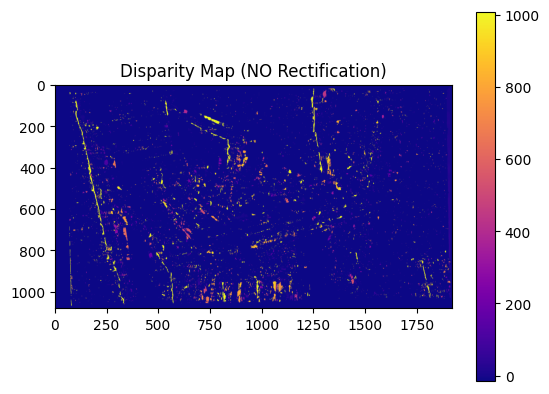

In [ ]:
# --- Disparity WITHOUT rectification (raw stereo images) ---
stereo_no_rect = cv2.StereoBM_create(numDisparities=64, blockSize=15)

# --- Timing unrectified ---
start = time.time()
disparity_no_rect = stereo_no_rect.compute(img1, img2)
end = time.time()
elapsed_ms_no_rect = (end - start) * 1000
print(f"Time for unrectified images: {elapsed_ms_no_rect:.2f} ms")

plt.imshow(disparity_no_rect, cmap='plasma')
plt.colorbar()
plt.title("Disparity Map (NO Rectification)")
plt.show()

Time for rectified images: 93.26 ms


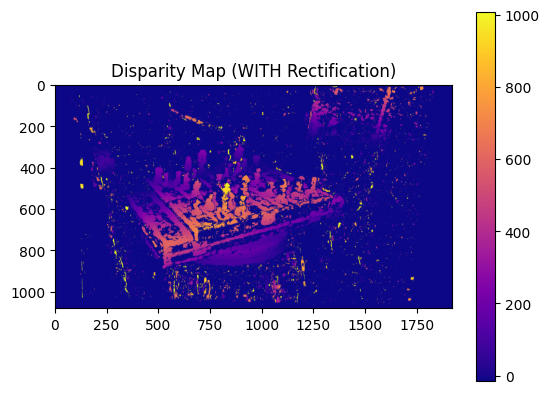

In [ ]:
# --- Disparity WITH rectification ---
stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)

# --- Timing rectified ---
start = time.time()
disparity = stereo.compute(img1_rect, img2_rect)
end = time.time()
elapsed_ms_rect = (end - start) * 1000
print(f"Time for rectified images: {elapsed_ms_rect:.2f} ms")

plt.imshow(disparity, cmap='plasma')
plt.colorbar()
plt.title("Disparity Map (WITH Rectification)")
plt.show()